<a href="https://colab.research.google.com/github/Maryum58/House_Price_Prediction/blob/main/HousePricePrediction_MaryumAli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [14]:
data=pd.read_csv('/content/data.csv')

In [15]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

Cleaning the dataset


In [17]:
data = data[data['price'] > 0]

In [18]:
data = data[data['price'] < 2000000]

In [27]:
import pandas as pd

data = pd.read_csv('/content/data.csv')
data = data[data['price'] > 0]
data = data[data['price'] < 2000000]

X = data[['bedrooms','bathrooms','sqft_living','floors','sqft_lot','condition', 'city', 'yr_built','statezip', 'yr_renovated', 'view']]
X = pd.get_dummies(X, columns=['city', 'statezip'], drop_first=True)
y = data['price']

Splitting Training and Testing data


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression


In [40]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 84697.43871589947
Linear Regression R2: 0.7853496706035503


Model Training- Random Forest Regressor


In [29]:
model = RandomForestRegressor(n_estimators=1000)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000)

In [30]:
predictions = model.predict(X_test)

Checking Mean Absolute Error


In [31]:


mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 88696.33376363348


In [32]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.7561213510339356


Training another model using Gradient Boosting Regressor

In [49]:


gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting MAE: 95866.30690450326
Gradient Boosting R2: 0.7506573121005693


New House Price Prediction


In [44]:
new_house = pd.DataFrame({
    'bedrooms':[4],
    'bathrooms':[3],
    'sqft_living':[2500],
    'floors':[2],
    'sqft_lot':[6000],
    'condition':[4],
    'city':['Seattle'],
    'yr_built':[2005],
    'statezip':['WA 98103'],
    'yr_renovated':[0],
    'view':[1]
})

# Apply the same one-hot encoding to new_house as to X_train
new_house_processed = pd.get_dummies(new_house, columns=['city', 'statezip'], drop_first=True)

# Align columns with the training data (X_train), filling missing columns with 0
# This ensures that all one-hot encoded columns from training are present,
# even if the new_house does not have values for all categories.
new_house_aligned = new_house_processed.reindex(columns=X_train.columns, fill_value=0)

prediction = model.predict(new_house_aligned)

print("Predicted House Price:", prediction[0])

Predicted House Price: 492126.012736265


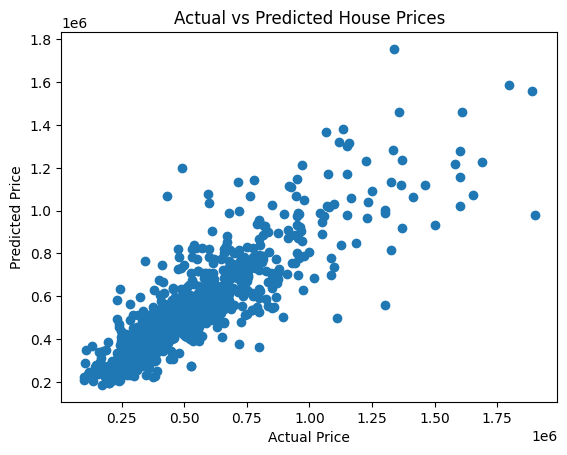

In [45]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

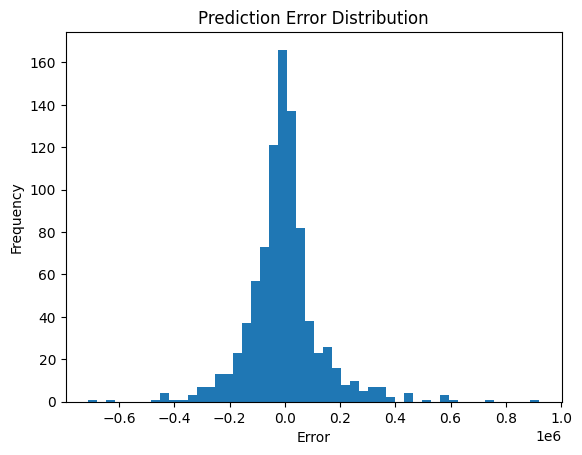

In [46]:
errors = y_test - predictions

import matplotlib.pyplot as plt

plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [48]:


results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_mae, mae, gb_mae],
    "R2 Score": [lr_r2, r2, gb_r2]
})

print(results)

               Model           MAE  R2 Score
0  Linear Regression  84697.438716  0.785350
1      Random Forest  88696.333764  0.756121
2  Gradient Boosting  95784.262413  0.750920


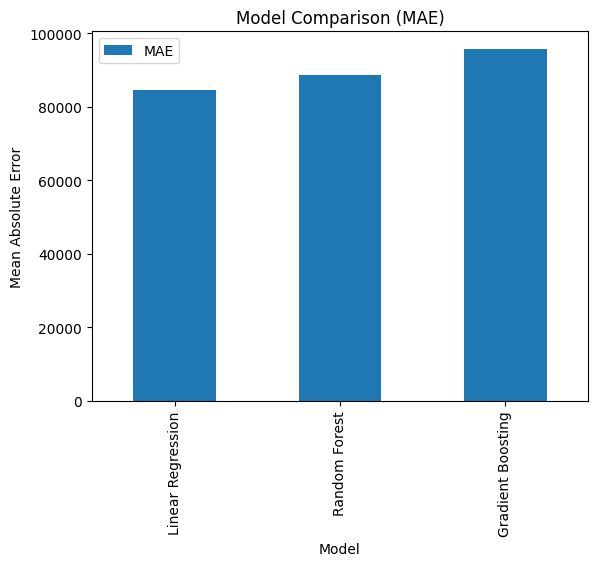

In [51]:


results.plot(x="Model", y="MAE", kind="bar")

plt.title("Model Comparison (MAE)")
plt.ylabel("Mean Absolute Error")

plt.show()

In [54]:
pickle.dump(r2, open("house_price_model.pkl", "wb"))

In [55]:
feature_columns = X.columns

pickle.dump(feature_columns, open("features.pkl", "wb"))